In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st

# Esercizio 1
## 1.1
può assumere valori >= 1 in quanto ha come supporto i numeri interi positivi. per questo inoltre NON può assumere valori negativi
## 1.4


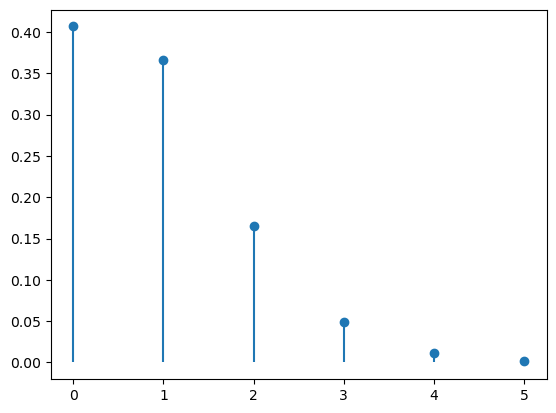

In [5]:
lamb = 0.9
X = st.poisson(lamb)
x = np.arange(0, 6)
plt.vlines(x,0,X.pmf(x))
plt.plot(x,X.pmf(x), 'o')
plt.show()

dato che il supporto è discreto e assume solo valori interi >= 0 ho costruito un grafico a bastoncini per evidenziare i punti di massa.
inoltre ho scelto 5 come valore massimo per le ascisse in quanto si avvicinava già molto allo 0 e valori successivi tendono sempre di più allo 0, andando a schiacciare il grafico e non aggiungendo informazioni utili all'interpretazione

## 1.5
S segue una distribuzione di poisson per le proprietà della distribuzione poissoniana

## 2.1
T è uno stimatore non deviato per lambda in quanto abbiamo che come da foglio protocollo il valore atteso è lambda

U invece non lo è in quanto il suo valore atteso vale $\frac{5}{2} \lambda$

non possiamo valutarne la consistenza in media quadratica in quanto la taglia del campione è stata fissata.
## 2.2

In [6]:
ril = pd.read_csv("data/rilevazioni.csv", sep=";")
ril.head()

,temperatura,blocchidanneggiati,raffreddamento
0,46.024489,0.0,1.0
1,83.225486,0.0,1.0
2,81.451565,0.0,NaN
3,54.427135,0.0,1.0
4,76.438674,0.0,1.0


In [7]:
# 3.1
print(len(ril))
print(len(ril[(ril.temperatura.isna()) | (ril.blocchidanneggiati.isna()) | (ril.raffreddamento.isna())]))
print(ril.columns[ril.isna().any()])

1727
5
Index(['raffreddamento'], dtype='object')


<Axes: xlabel='raffreddamento'>

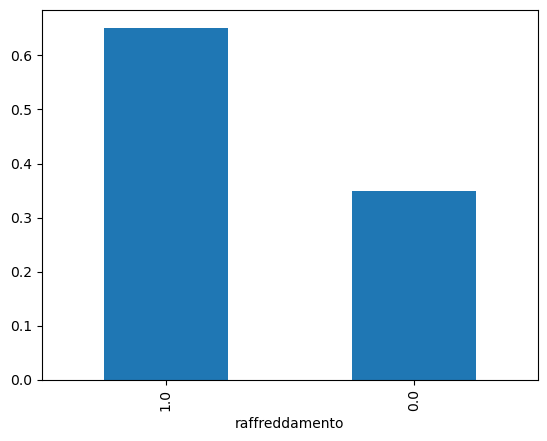

In [8]:
# 3.2
ril.raffreddamento.value_counts(normalize=True).plot.bar()

In [9]:
ril.raffreddamento.value_counts(normalize=True)

raffreddamento
1.0    0.651568
0.0    0.348432
Name: proportion, dtype: float64

il risultato ottenuto è che il raffreddamento addizionale è stato attivato almeno una volta nel 65% dei casi mentre per il 34% dei casi è rimasto spento. ho scelto un grafico a barre perchè mi permette di visualizzare le frequenze in maniera semplice ed essendo un attributo di tipo binario il numero di barre è solo 2. avrei potuto usare anche un grafico a torta.

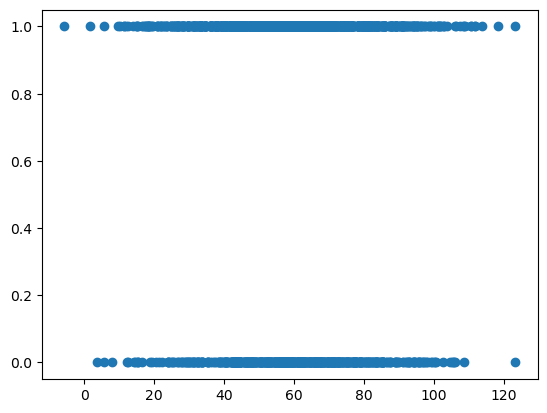

In [10]:
# 2.3
plt.scatter(ril.temperatura, ril.raffreddamento)

In [11]:
# non sembrano essere correlati ma per sicurezza vado a calcolare il coefficente di correlazione lineare
ril.temperatura.corr(ril.raffreddamento) # infatti è vicino allo 0. la temperatura quindi non influisce sul sistema di raffreddamento.

-0.046219473361162826

per valutare questa ipotesi ho utilizzato una scatter plot, che mi permette di visualizzare in maniera grafica come i due attributi sono correlati.
se esiste una correlazione lineare diretta avrò che i puntini del grafico si allineano in una retta con coeff angolare positivo mentre se sono in presenza di una corr lineare inversa allora
si andranno ad allineare circa su una retta con coeff angolare negativo. in questo caso non si allineano su una retta (ma su sovrapposte) quindi non sembra esserci correalzione.
per esesrne sicuro calcolo poi il coefficente di correlazione lineare che mi permette dati due campioni di calcolare quanto è forte
la relazione che li lega, e ottenendo un valore vicino allo 0 ottengo che non sono legati da una relazione lineare.

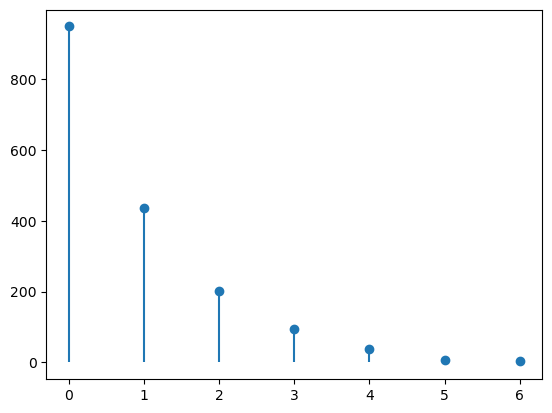

In [12]:
## 3.4
frBlocchi = ril.blocchidanneggiati.value_counts()
plt.vlines(frBlocchi.index,0, frBlocchi)
plt.plot(frBlocchi.index, frBlocchi, 'o')

ho ottenuto un grafico che mostra che è molto più probabile avere un'ora con nessun blocco danneggiato e maggiore è il numero di blocchi danneggiati minore è la probabilità di ottenerlo.
ho scelto un grafico a bastoncini in quanto sto andando a rappresentare frequenze assolute di rilevazioni che sono numeri interi, quindi con un dominio discreto.

In [13]:
## 3.5
cr = pd.crosstab(ril.blocchidanneggiati, ril.raffreddamento)
cr

raffreddamento,0.0,1.0
blocchidanneggiati,,
0.0,116,830
1.0,181,253
2.0,166,34
3.0,89,5
4.0,37,0
5.0,8,0
6.0,3,0


In [14]:
# P(D)
p_d =1-((116+830)/ril.blocchidanneggiati.sum())
print(p_d)

0.28603773584905656


In [15]:
# P(R ind D)
P_rd = (253+34+5)/(830+253+34+5)
P_rd

0.26024955436720143

In [16]:
# P(D | R)
raff = ril.raffreddamento.value_counts()
P_r = raff[1.0]/(raff[0]+raff[1.0])
P_rd/P_r

0.3994204390555445

In [17]:
cr

raffreddamento,0.0,1.0
blocchidanneggiati,,
0.0,116,830
1.0,181,253
2.0,166,34
3.0,89,5
4.0,37,0
5.0,8,0
6.0,3,0


In [18]:
cr[0].sum()/(cr[0].sum()+cr[1].sum())

0.34843205574912894

In [19]:
p_dinv = 1-p_d

p_rd_inv = (cr[0].sum()/(cr[0].sum()+cr[1].sum()))/p_dinv
p_rd_inv

0.48802587089597865

In [20]:
# Esercizio 4
## 4.1
raffreddamento_si = ril[ril.raffreddamento == 1]["blocchidanneggiati"]
raffreddamento_no = ril[ril.raffreddamento == 0]["blocchidanneggiati"]
raffreddamento_no

1125    0.0
1126    0.0
1127    0.0
1128    0.0
1129    0.0
       ... 
1722    5.0
1723    5.0
1724    6.0
1725    6.0
1726    6.0
Name: blocchidanneggiati, Length: 600, dtype: float64

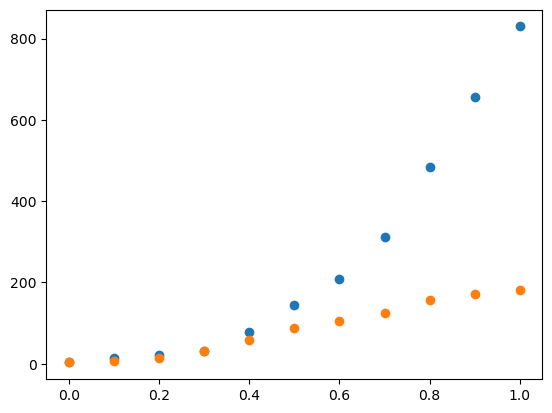

In [30]:
## 4.2
x = np.arange(0,1.1,0.1)

quant_si = raffreddamento_si.value_counts().quantile(x)
quant_no = raffreddamento_no.value_counts().quantile(x)
plt.plot(x, quant_si, 'o')
plt.plot(x, quant_no, 'o')

guardando il grafico creato vedo che è molto più probabile che vi siano blocchi danneggiati quando il sistema di raffreddamento non è attivo che quando lo è. questo si nota dal fatto che la linea non è a quaranacinque gradi (lo sarebbe se il sistema di affreddamento non influisse sul danneggiamento dei blocchi).

In [22]:
# 4.3
# stima per il valore atteso della distribuzione:
lam = raffreddamento_si.mean()
lam

0.2994652406417112

[-1.  0.  0.  0.  0.  0.  0.  0.  1.  1. inf]


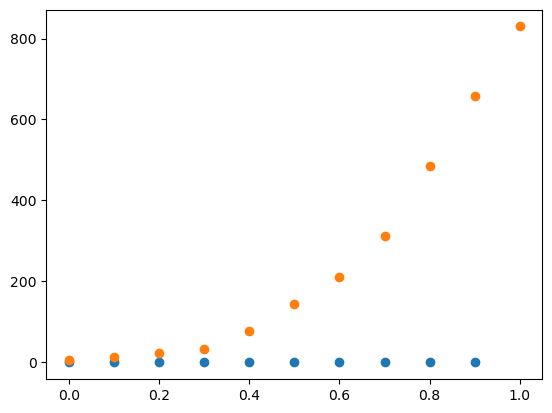

In [31]:
# 4.4
x = np.arange(0,1.1,0.1)

p = st.poisson(lam)
quant_p = p.ppf(x)
print(quant_p)
plt.plot(quant_si, quant_p, 'o')
plt.plot(quant_si, quant_p, 'o')

varianza X_si: la media campionaria
deviazione standard di X_si: radice quad della media campionaria
par lambda: sempre media campionaria in quanto valore atteso è uguale al parametro lambda

sono tutti consistenti in MSE 

In [24]:
## 4.8
raff[1]/(raff[1]+raff[0])

0.6515679442508711

In [25]:
## 4.9
lam_si = raffreddamento_si.mean()
lam_no = raffreddamento_no.mean()

poi_si = st.poisson(lam_si)
poi_no = st.poisson(lam_no)

print("con raff in funzione:", poi_si.pmf(4))
print("senza raff in funzione:", poi_no.pmf(4))

con raff in funzione: 0.0002483809813456012
senza raff in funzione: 0.05874904589732197


In [26]:
# 4.10
poi = st.poisson(ril.blocchidanneggiati.mean())
print(1-poi.cdf(4))

0.0011760210899806056


In [27]:
## 4.11
P_a = 1-poi.cdf(4)
(1-poi.cdf(4))*7

0.00823214762986424